# ROUND1 EDA — `ASH_COATED_OSMIUM` & `INTARIAN_PEPPER_ROOT`

Visual exploration of the order book snapshots (`prices_round_1_day_*.csv`) and executed trades (`trades_round_1_day_*.csv`) in the `ROUND1/` folder.

**Sections**
1. Load & stitch the 3 days (−2, −1, 0)
2. Mid-price time series per product
3. Spread & book depth
4. Returns distribution & volatility
5. Rolling statistics (mean, std)
6. Autocorrelation of returns
7. Cross-product relationship (level + returns)
8. Executed trades — price/volume over time
9. Microprice vs mid (order-flow imbalance signal)

Products are abbreviated as:
- **ACO** = `ASH_COATED_OSMIUM`
- **IPR** = `INTARIAN_PEPPER_ROOT`

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

_candidates = [Path("ROUND1"), Path(".")]
DATA_DIR = next((c for c in _candidates if list(c.glob("prices_round_1_day_*.csv"))), Path("ROUND1"))
PRODUCTS = ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]
SHORT = {"ASH_COATED_OSMIUM": "ACO", "INTARIAN_PEPPER_ROOT": "IPR"}
COLORS = {"ACO": "#1f77b4", "IPR": "#d62728"}

## 1. Load prices & trades across all days

Each day has its own timestamp starting at 0. We create a global `t` = `day * 1_000_000 + timestamp` so the 3 days lay out end-to-end on a single axis.

In [7]:
def load_prices(folder: Path) -> pd.DataFrame:
    frames = []
    for p in sorted(folder.glob("prices_round_1_day_*.csv")):
        frames.append(pd.read_csv(p, sep=";"))
    df = pd.concat(frames, ignore_index=True)
    day_offset = (df["day"] - df["day"].min()) * 1_000_000
    df["t"] = day_offset + df["timestamp"]
    return df.sort_values(["t", "product"]).reset_index(drop=True)

def load_trades(folder: Path) -> pd.DataFrame:
    frames = []
    for p in sorted(folder.glob("trades_round_1_day_*.csv")):
        d = pd.read_csv(p, sep=";")
        day_num = int(str(p).split("day_")[-1].split(".")[0])
        d["day"] = day_num
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    day_offset = (df["day"] - df["day"].min()) * 1_000_000
    df["t"] = day_offset + df["timestamp"]
    return df.sort_values("t").reset_index(drop=True)

prices = load_prices(DATA_DIR)
trades = load_trades(DATA_DIR)
print("prices rows:", len(prices), "| days:", sorted(prices['day'].unique()))
print("trades rows:", len(trades), "| products:", trades['symbol'].unique())
prices.head()

prices rows: 60000 | days: [-2, -1, 0]
trades rows: 2276 | products: ['ASH_COATED_OSMIUM' 'INTARIAN_PEPPER_ROOT']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,t
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
1,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
2,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100
3,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100
4,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,200


In [8]:
def pivot_mid(df: pd.DataFrame) -> pd.DataFrame:
    m = df.pivot_table(index="t", columns="product", values="mid_price", aggfunc="last")
    m = m.sort_index().ffill().dropna()
    m.columns = [SHORT[c] for c in m.columns]
    return m

mids = pivot_mid(prices)
mids.describe()

,ACO,IPR
count,30000.000000,30000.000000
mean,9983.870567,11479.188750
std,403.865355,993.184832
min,0.000000,0.000000
25%,9997.000000,10745.500000
50%,10000.500000,11497.500000
75%,10003.500000,12248.500000
max,10023.000000,13007.000000


## 2. Mid-price over time (per product, per day)

Vertical dashed lines mark day boundaries.

_Mid-price for each product across the 3 days, with dashed lines marking day boundaries. Confirms one product is pinned near a round number (low vol) and one drifts (high vol) — informs whether to mean-revert or trend-follow each side._


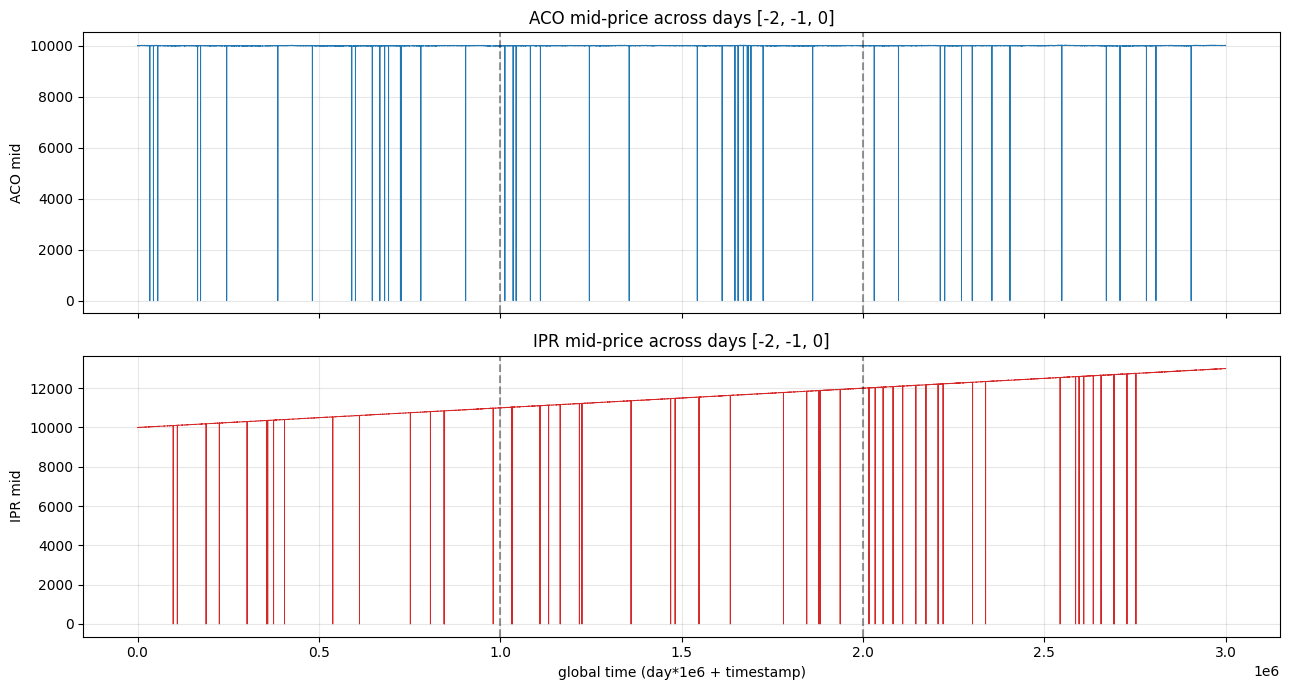

In [9]:
day_breaks = sorted(prices["day"].unique())
day_bounds = [(d - min(day_breaks)) * 1_000_000 for d in day_breaks]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, col in zip(axes, ["ACO", "IPR"]):
    ax.plot(mids.index, mids[col], color=COLORS[col], lw=0.7)
    ax.set_ylabel(f"{col} mid")
    ax.set_title(f"{col} mid-price across days {day_breaks}")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[-1].set_xlabel("global time (day*1e6 + timestamp)")
plt.tight_layout()
plt.show()

## 3. Spread (best ask − best bid) and top-of-book depth

_Top: spread (`ask₁ − bid₁`) histogram per product. Tighter histogram = competitive book. Bottom: total top-of-book depth distribution — fatter right tail = thicker liquidity, easier to size into._


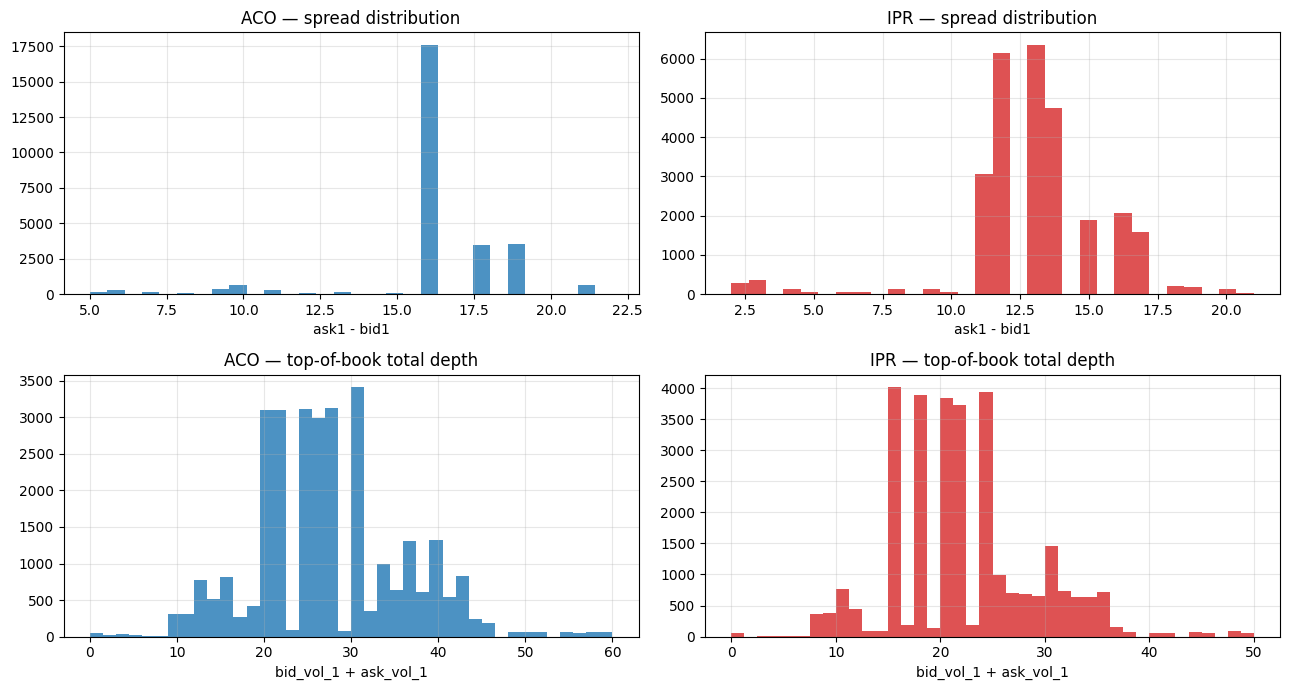

product          ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
spread    count       27644.000000          27688.000000
          mean           16.175228             13.046699
          std             2.570999              2.627145
          min             5.000000              2.000000
          25%            16.000000             12.000000
          50%            16.000000             13.000000
          75%            18.000000             14.000000
          max            22.000000             21.000000
depth_top count       30000.000000          30000.000000
          mean           27.151667             22.156800
          std             8.576339              6.852555
          min             0.000000              0.000000
          25%            22.000000             18.000000
          50%            26.000000             22.000000
          75%            31.000000             25.000000
          max            60.000000             50.000000

In [10]:
p = prices.copy()
p["spread"] = p["ask_price_1"] - p["bid_price_1"]
p["depth_top"] = p["ask_volume_1"].fillna(0) + p["bid_volume_1"].fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for i, prod in enumerate(PRODUCTS):
    sub = p[p["product"] == prod]
    c = COLORS[SHORT[prod]]
    axes[0, i].hist(sub["spread"].dropna(), bins=30, color=c, alpha=0.8)
    axes[0, i].set_title(f"{SHORT[prod]} — spread distribution")
    axes[0, i].set_xlabel("ask1 - bid1")
    axes[1, i].hist(sub["depth_top"], bins=40, color=c, alpha=0.8)
    axes[1, i].set_title(f"{SHORT[prod]} — top-of-book total depth")
    axes[1, i].set_xlabel("bid_vol_1 + ask_vol_1")
plt.tight_layout()
plt.show()

p.groupby("product")[["spread", "depth_top"]].describe().T

## 4. Returns distribution & volatility

_Per-tick log-return distributions in basis points, clipped to 0.1–99.9% so a single jump doesn't wreck the histogram. The σ in the title is your raw per-tick volatility — the ratio between products tells you who needs wider quotes._


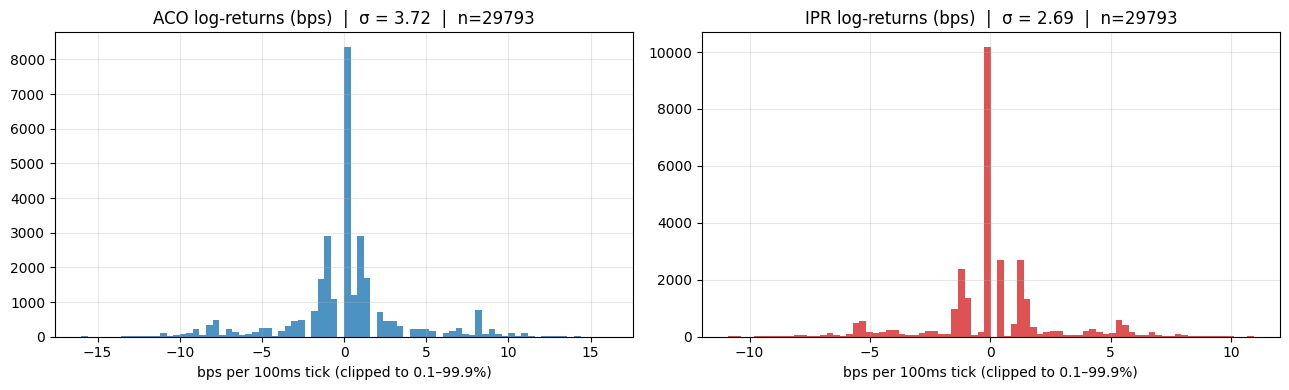

summary (bps):
         mean       std        min        max
ACO -0.001141  3.717838 -21.015770  21.003158
IPR  0.087151  2.692048 -15.846469  13.874973


In [11]:
mids_pos = mids.where(mids > 0)
rets = np.log(mids_pos).diff() * 1e4  # bps
rets = rets.replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["ACO", "IPR"]):
    x = rets[col].to_numpy()
    x = x[np.isfinite(x)]
    if x.size == 0:
        ax.set_title(f"{col} — no finite returns")
        continue
    lo, hi = np.quantile(x, [0.001, 0.999])
    xc = x[(x >= lo) & (x <= hi)] if hi > lo else x
    ax.hist(xc, bins=80, color=COLORS[col], alpha=0.8)
    ax.set_title(f"{col} log-returns (bps)  |  σ = {x.std():.2f}  |  n={len(x)}")
    ax.set_xlabel("bps per 100ms tick (clipped to 0.1–99.9%)")
plt.tight_layout()
plt.show()

print("summary (bps):")
print(rets.agg(["mean", "std", "min", "max"]).T)

## 5. Rolling mean & std (window = 100 ticks ≈ 10s)

_Rolling mean (top) and rolling σ (bottom) over a 100-tick (~10s) window. Flat rolling mean + bounded rolling σ = stationary regime suitable for symmetric MM quotes; trending mean = need to skew quotes with the drift._


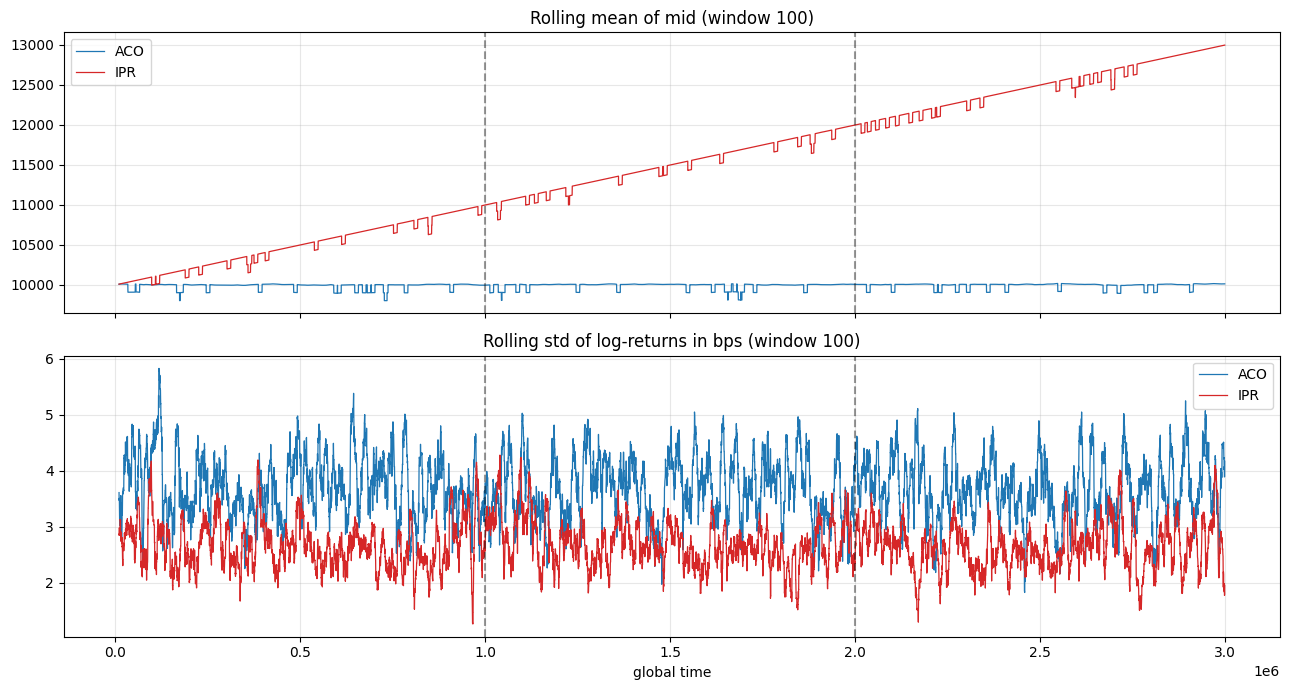

In [12]:
WIN = 100
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for col in ["ACO", "IPR"]:
    axes[0].plot(mids.index, mids[col].rolling(WIN).mean(), color=COLORS[col], label=col, lw=0.9)
    axes[1].plot(rets.index, rets[col].rolling(WIN).std(), color=COLORS[col], label=col, lw=0.9)
axes[0].set_title(f"Rolling mean of mid (window {WIN})")
axes[0].legend()
axes[1].set_title(f"Rolling std of log-returns in bps (window {WIN})")
axes[1].set_xlabel("global time")
axes[1].legend()
for b in day_bounds[1:]:
    for ax in axes:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Autocorrelation of returns

Negative short-lag ACF ⇒ mean-reverting micro-structure, which favors aggressive mid reversion / microprice fair.

_Autocorrelation of log-returns at lags 0..30. **Negative bars at small lags ⇒ mean-reverting microstructure**, which favours an aggressive microprice fair / aggressive reversion to mid. Positive bars = momentum, favours skew-following._


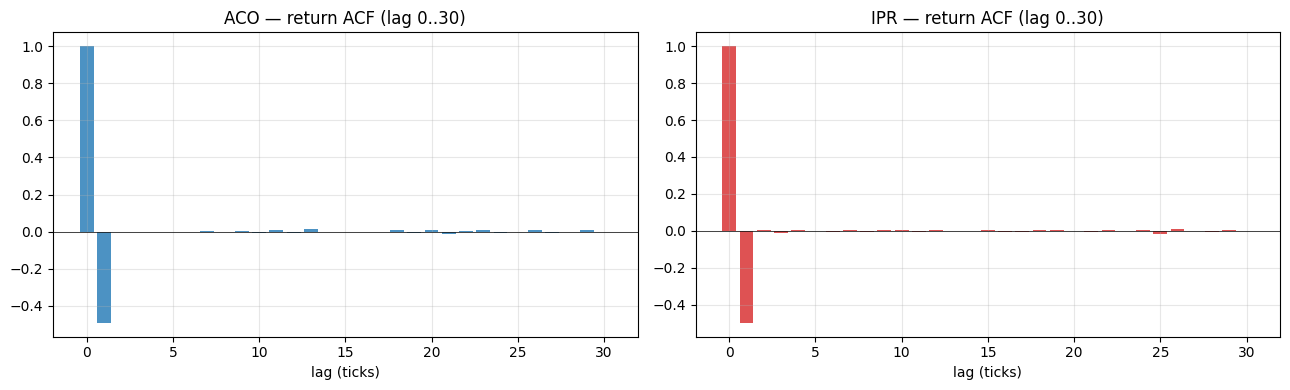

In [13]:
def acf(x: np.ndarray, lags: int = 30) -> np.ndarray:
    x = x - x.mean()
    v = np.dot(x, x)
    if v < 1e-20:
        return np.full(lags + 1, np.nan)
    return np.array([np.dot(x[: len(x) - k], x[k:]) / v for k in range(lags + 1)])

LAGS = 30
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["ACO", "IPR"]):
    a = acf(rets[col].values, LAGS)
    ax.bar(range(LAGS + 1), a, color=COLORS[col], alpha=0.8)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{col} — return ACF (lag 0..{LAGS})")
    ax.set_xlabel("lag (ticks)")
plt.tight_layout()
plt.show()

## 7. Cross-product relationship

_Left: scatter of mid levels (ACO vs IPR) — Pearson r in title. Right: scatter of bps returns. Below: lagged Pearson(ACO_ret(t), IPR_ret(t+L)). A non-zero peak at any lag = one product leads/lags the other = pair-trade alpha._


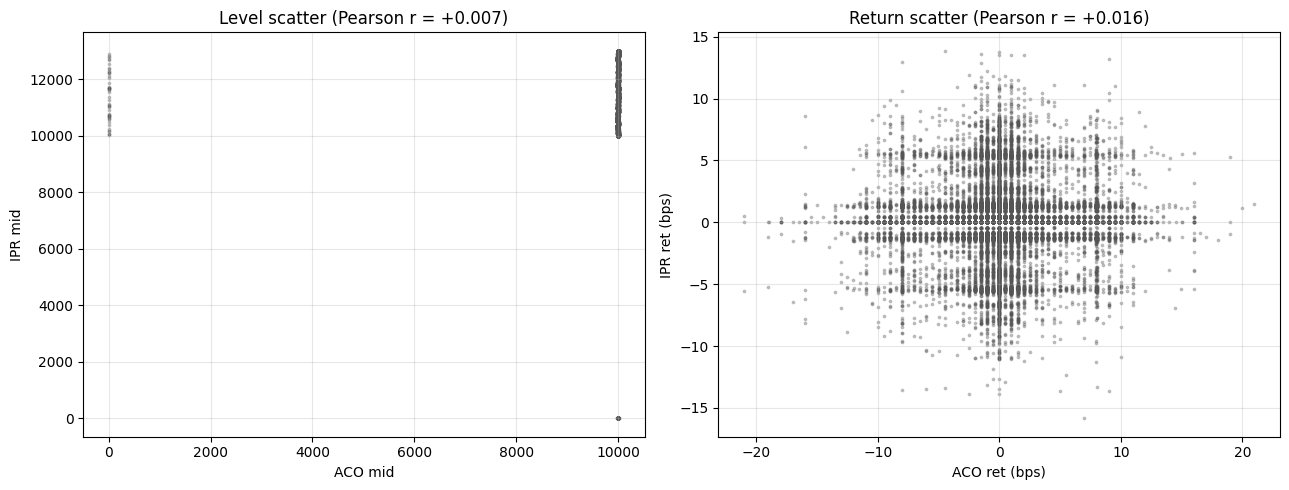

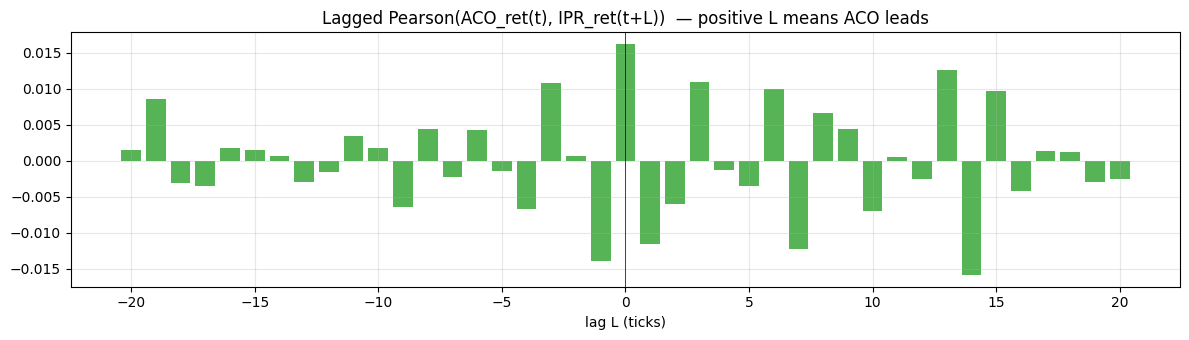

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(mids["ACO"], mids["IPR"], s=3, alpha=0.3, color="#555")
axes[0].set_xlabel("ACO mid"); axes[0].set_ylabel("IPR mid")
axes[0].set_title(f"Level scatter (Pearson r = {mids.corr().iloc[0,1]:+.3f})")

axes[1].scatter(rets["ACO"], rets["IPR"], s=3, alpha=0.3, color="#555")
axes[1].set_xlabel("ACO ret (bps)"); axes[1].set_ylabel("IPR ret (bps)")
axes[1].set_title(f"Return scatter (Pearson r = {rets.corr().iloc[0,1]:+.3f})")
plt.tight_layout()
plt.show()

lags = range(-20, 21)
ac = rets["ACO"].values; ip = rets["IPR"].values
xcorr = []
for L in lags:
    if L >= 0:
        a, b = ac[: len(ac) - L], ip[L:]
    else:
        a, b = ac[-L:], ip[: len(ip) + L]
    if len(a) < 5 or a.std() == 0 or b.std() == 0:
        xcorr.append(np.nan); continue
    xcorr.append(float(np.corrcoef(a, b)[0, 1]))

plt.figure(figsize=(12, 3.5))
plt.bar(list(lags), xcorr, color="#2ca02c", alpha=0.8)
plt.axvline(0, color="k", lw=0.5)
plt.title("Lagged Pearson(ACO_ret(t), IPR_ret(t+L))  — positive L means ACO leads")
plt.xlabel("lag L (ticks)")
plt.tight_layout()
plt.show()

## 8. Executed trades — price & volume over time

_Mid (grey line) overlaid with executed trades (scatter, size & colour = quantity). Trades clustering above mid = aggressive buyers; below = aggressive sellers. Tells you where toxic flow concentrates and which direction to lean a quote skew._


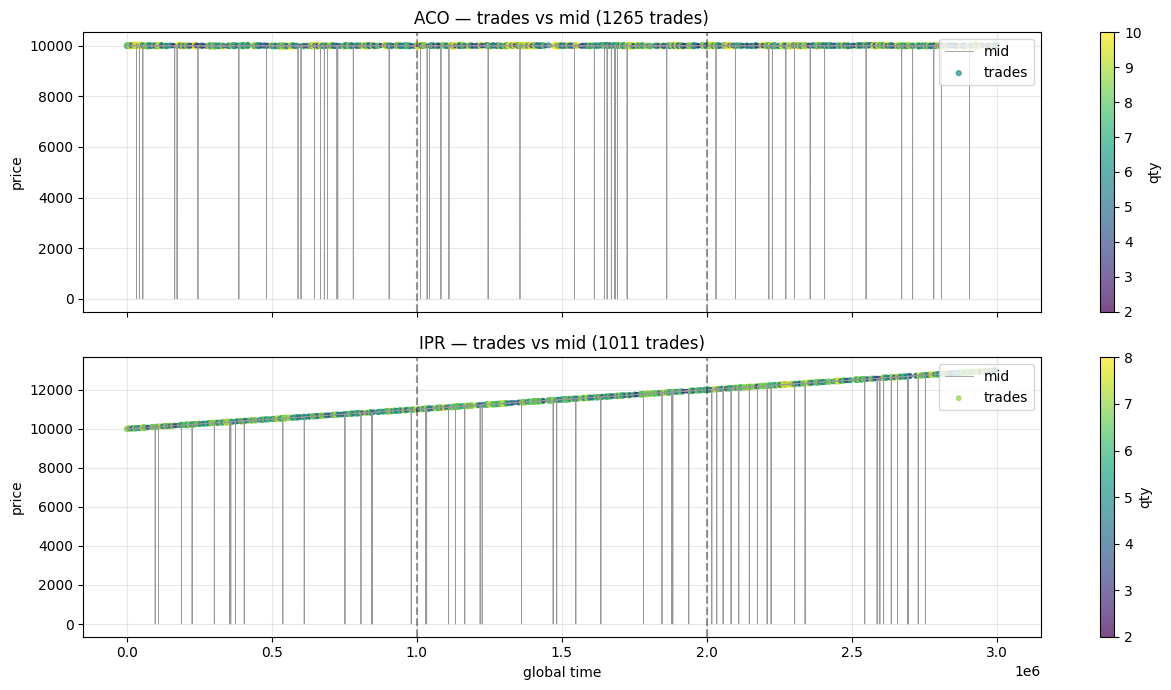

trade qty & price summary per product:


symbol          ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
price    count        1265.000000           1011.000000
         mean        10000.213439          11495.941642
         std             9.398204            879.805548
         min          9979.000000           9995.000000
         25%          9992.000000          10736.000000
         50%         10000.000000          11502.000000
         75%         10008.000000          12251.000000
         max         10026.000000          13005.000000
quantity count        1265.000000           1011.000000
         mean            5.211858              5.173096
         std             2.275214              1.511903
         min             2.000000              2.000000
         25%             3.000000              4.000000
         50%             5.000000              5.000000
         75%             6.000000              6.000000
         max            10.000000              8.000000

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for i, prod in enumerate(PRODUCTS):
    ax = axes[i]
    tr = trades[trades["symbol"] == prod]
    mid_sub = prices[prices["product"] == prod][["t", "mid_price"]]
    ax.plot(mid_sub["t"], mid_sub["mid_price"], color="#999", lw=0.6, label="mid")
    sc = ax.scatter(tr["t"], tr["price"], s=np.clip(tr["quantity"] * 2, 4, 80),
                    c=tr["quantity"], cmap="viridis", alpha=0.7, label="trades")
    plt.colorbar(sc, ax=ax, label="qty")
    ax.set_title(f"{SHORT[prod]} — trades vs mid ({len(tr)} trades)")
    ax.set_ylabel("price")
    ax.legend(loc="upper right")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[-1].set_xlabel("global time")
plt.tight_layout()
plt.show()

print("trade qty & price summary per product:")
trades.groupby("symbol")[["price", "quantity"]].describe().T

## 9. Microprice vs mid — order-flow imbalance signal

Microprice = `ask * (bid_vol / total) + bid * (ask_vol / total)` — pulls fair toward the heavier side of the book. The deviation `micro − mid` is a short-horizon directional signal.

_Microprice = `ask·(bid_vol/total) + bid·(ask_vol/total)` — pulls the fair toward the heavier side of the book. Histogram of `microprice − mid` shows how often (and how far) the fair deviates from mid. Mean ≠ 0 = systematic bias to exploit._


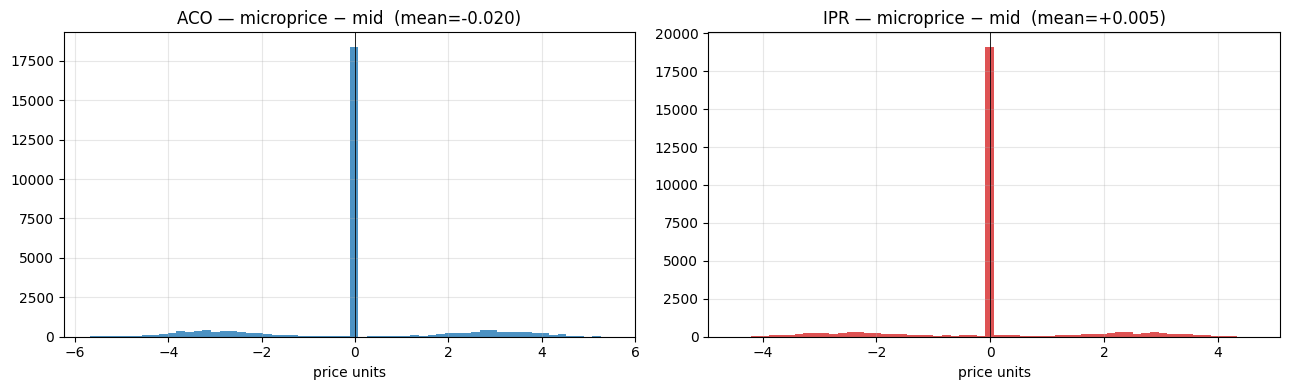

In [16]:
q = prices.copy()
bv = q["bid_volume_1"].fillna(0); av = q["ask_volume_1"].fillna(0)
tot = (bv + av).replace(0, np.nan)
q["micro"] = q["ask_price_1"] * (bv / tot) + q["bid_price_1"] * (av / tot)
q["micro_dev"] = q["micro"] - q["mid_price"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, prod in zip(axes, PRODUCTS):
    sub = q[q["product"] == prod]["micro_dev"].dropna()
    ax.hist(sub, bins=60, color=COLORS[SHORT[prod]], alpha=0.8)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{SHORT[prod]} — microprice − mid  (mean={sub.mean():+.3f})")
    ax.set_xlabel("price units")
plt.tight_layout()
plt.show()

---
### Takeaways to look for
- Is one product pinned near a round number (low vol) while the other drifts (high vol)?
- Short-lag ACF sign → favors microprice (negative) vs momentum (positive).
- Cross-return correlation → whether a pair signal / hedge is viable.
- Trade clusters relative to mid → where aggressors pay up; informs passive edge vs cross-the-spread PnL.

## 10. Order book ladder over time (per product)

For each product we stack the top-3 levels of bid and ask **volumes** at their **prices** through time. Blue cells = bid volume resting at that price, red cells = ask volume, black line = mid.

This is the most honest picture of what the book actually looks like: where liquidity sits, where holes open up, and how the MM's passive ladder moves.

_Order-book ladder heatmap per product. Blue cells = resting bid volume at that price, red = resting ask volume, black line = mid. The most honest picture of where liquidity actually sits, where holes open up, and how the MM ladder moves through time._


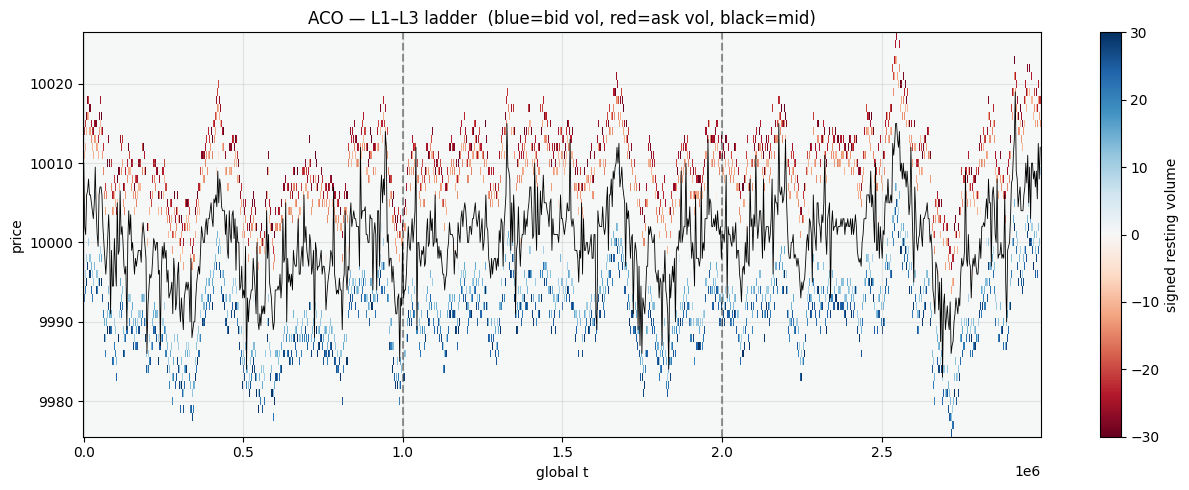

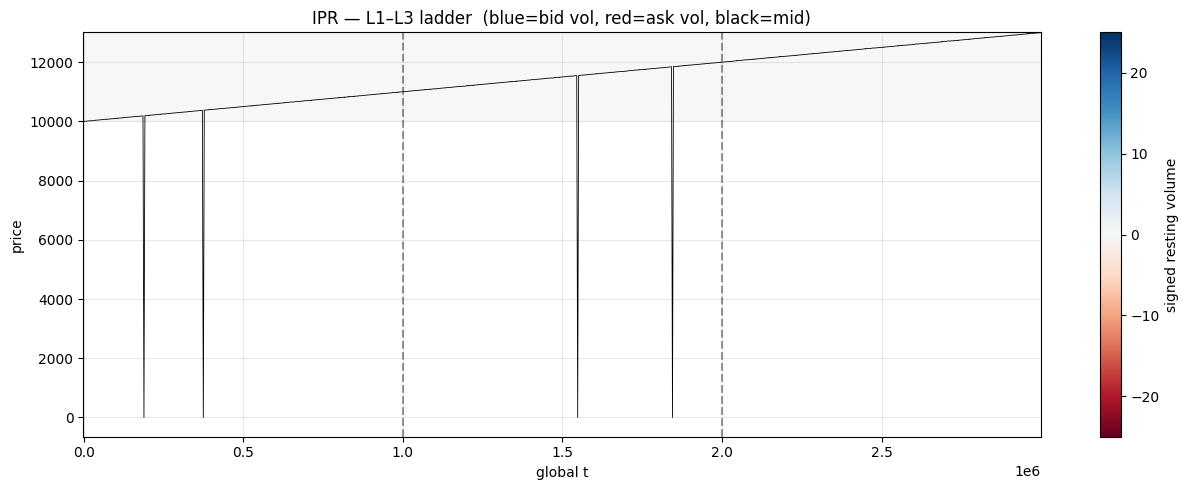

In [17]:
def book_heatmap(prices_df, product, tick_step=30, levels=3):
    sub = prices_df[prices_df["product"] == product].iloc[::tick_step].reset_index(drop=True)
    all_prices = []
    for lvl in range(1, levels + 1):
        all_prices += sub[f"bid_price_{lvl}"].dropna().astype(int).tolist()
        all_prices += sub[f"ask_price_{lvl}"].dropna().astype(int).tolist()
    if not all_prices:
        return
    p_min, p_max = min(all_prices), max(all_prices)
    price_axis = np.arange(p_min, p_max + 1)
    grid = np.zeros((len(price_axis), len(sub)))

    for j in range(len(sub)):
        row = sub.iloc[j]
        for lvl in range(1, levels + 1):
            bp, bv = row.get(f"bid_price_{lvl}"), row.get(f"bid_volume_{lvl}")
            ap, av = row.get(f"ask_price_{lvl}"), row.get(f"ask_volume_{lvl}")
            if pd.notna(bp) and pd.notna(bv):
                grid[int(bp) - p_min, j] += float(bv)
            if pd.notna(ap) and pd.notna(av):
                grid[int(ap) - p_min, j] -= float(av)

    fig, ax = plt.subplots(figsize=(13, 5))
    vmax = np.abs(grid).max()
    im = ax.pcolormesh(sub["t"].values, price_axis, grid,
                       cmap="RdBu", vmin=-vmax, vmax=vmax, shading="auto")
    ax.plot(sub["t"].values, sub["mid_price"].values, color="k", lw=0.6)
    ax.set_ylabel("price"); ax.set_xlabel("global t")
    ax.set_title(f"{SHORT[product]} — L1–L{levels} ladder  (blue=bid vol, red=ask vol, black=mid)")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
    plt.colorbar(im, ax=ax, label="signed resting volume")
    plt.tight_layout(); plt.show()

for prod in PRODUCTS:
    book_heatmap(prices, prod)

## 11. Aggregate bid / ask depth over time

Cleaner view than the heatmap when we only care about **total size on each side**. Pink area = total bid volume across L1–L3, cyan = total ask volume, black = their signed sum (positive → buy pressure, negative → sell pressure).

_Aggregate L1+L2+L3 depth over time. Pink area above = total bid volume, blue area below = total ask volume, black line = signed net (bid − ask). Sustained positive net = buy pressure (skew quotes higher); sustained negative = sell pressure (skew lower)._


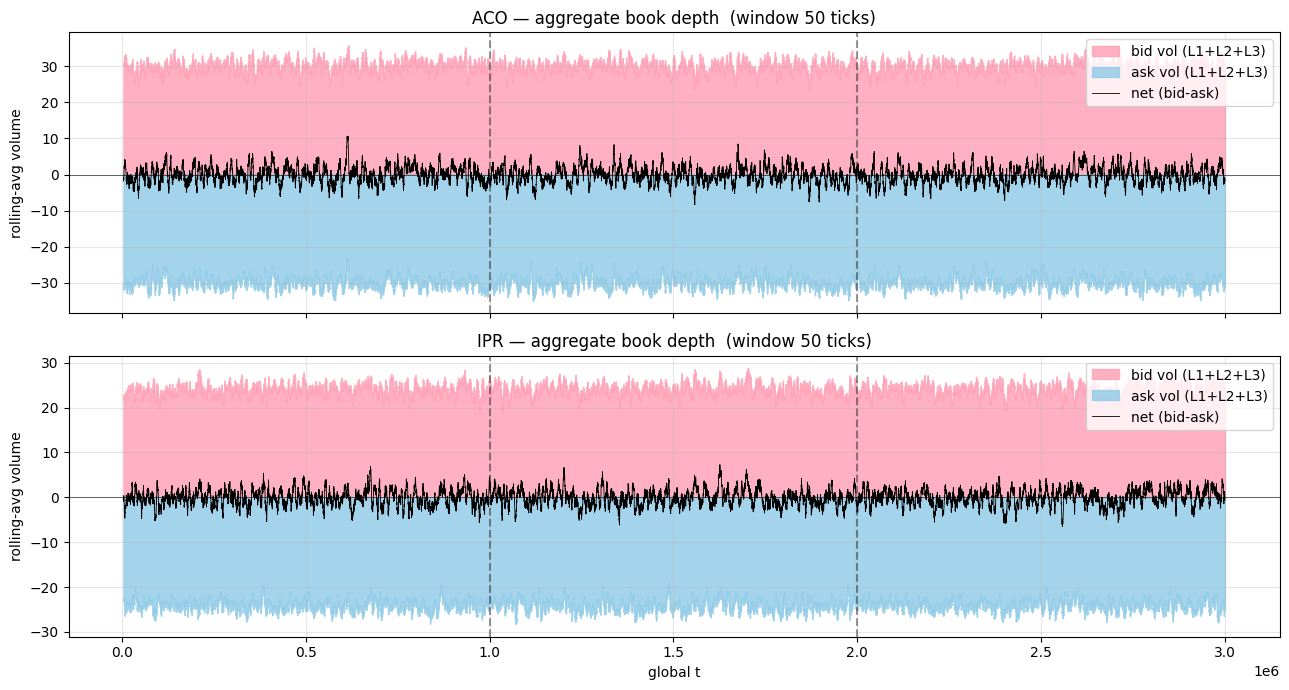

total book volume summary (all ticks, all days):
product            ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
bid_vol_tot count       30000.000000          30000.000000
            mean           30.107367             24.142500
            std            11.783225              9.563677
            min             0.000000              0.000000
            25%            23.000000             18.000000
            50%            34.000000             27.000000
            75%            39.000000             31.000000
            max            55.000000             47.000000
ask_vol_tot count       30000.000000          30000.000000
            mean           30.160733             24.226200
            std            11.754439              9.504542
            min             0.000000              0.000000
            25%            23.000000             18.000000
            50%            35.000000             27.000000
            75%            39.000000             31.000000
       

In [18]:
book = prices.copy()
book["bid_vol_tot"] = book[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].fillna(0).sum(axis=1)
book["ask_vol_tot"] = book[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].fillna(0).sum(axis=1)
book["depth_imb"] = book["bid_vol_tot"] - book["ask_vol_tot"]

SMOOTH = 50
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, prod in zip(axes, PRODUCTS):
    sub = book[book["product"] == prod].sort_values("t")
    bt = sub["bid_vol_tot"].rolling(SMOOTH).mean()
    at = sub["ask_vol_tot"].rolling(SMOOTH).mean()
    ax.fill_between(sub["t"], 0, bt, color="#ff9eb5", alpha=0.8, label="bid vol (L1+L2+L3)")
    ax.fill_between(sub["t"], 0, -at, color="#8ecae6", alpha=0.8, label="ask vol (L1+L2+L3)")
    ax.plot(sub["t"], (bt - at).values, color="k", lw=0.6, label="net (bid-ask)")
    ax.axhline(0, color="k", lw=0.4)
    ax.set_ylabel("rolling-avg volume")
    ax.set_title(f"{SHORT[prod]} — aggregate book depth  (window {SMOOTH} ticks)")
    ax.legend(loc="upper right")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[-1].set_xlabel("global t")
plt.tight_layout(); plt.show()

print("total book volume summary (all ticks, all days):")
print(book.groupby("product")[["bid_vol_tot", "ask_vol_tot", "depth_imb"]].describe().T)

## 12. Top-of-book imbalance (`imb1`) — signal strength & persistence

`imb1 = (bid_vol_1 − ask_vol_1) / (bid_vol_1 + ask_vol_1) ∈ [-1, +1]`

This is the signal the ACO trader monetises. Here we:

1. Look at its marginal distribution per product.
2. Bucket it and measure the **mean next-tick return** in each bucket — the stronger the edge at the extremes, the more useful the signal.
3. Compute the ACF of `imb1` itself — if it is persistent, our one-tick-ahead forecast generalises to several ticks; if it is white, the signal only lives for a single step.

_Three views of the imb1 signal: (1) marginal distribution per product, (2) bucketed mean next-tick Δmid — the magnitude in each bucket is your one-step predictive edge, (3) ACF of imb1 itself — persistent imb1 means the signal lasts more than one tick._


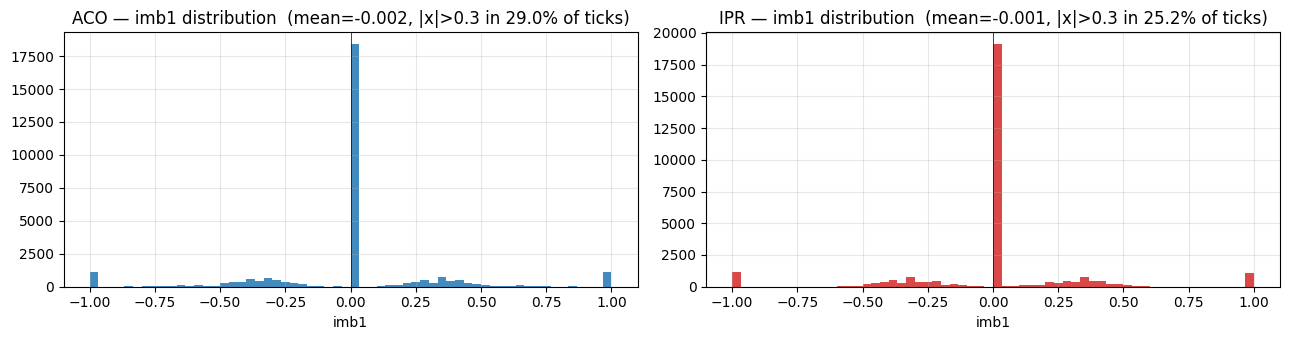

mean next-tick Δmid per imb1 bucket (price units):
                                      mean    std  count
product              imb_bucket                         
ASH_COATED_OSMIUM    (-1.001, -0.6] -6.788  3.751   1613
                     (-0.6, -0.3]   -1.781  2.946   2813
                     (-0.3, -0.1]   -1.497  2.941   1375
                     (-0.1, 0.1]     0.023  2.663  18432
                     (0.1, 0.3]      1.672  2.946   1408
                     (0.3, 0.6]      1.677  2.950   2786
                     (0.6, 1.0]      6.937  3.492   1523
INTARIAN_PEPPER_ROOT (-1.001, -0.6] -6.448  2.826   1208
                     (-0.6, -0.3]   -1.600  2.317   2580
                     (-0.3, -0.1]   -1.673  2.514   1553
                     (-0.1, 0.1]     0.121  2.238  19244
                     (0.1, 0.3]      1.878  2.540   1596
                     (0.3, 0.6]      1.828  2.421   2632
                     (0.6, 1.0]      6.519  2.775   1132


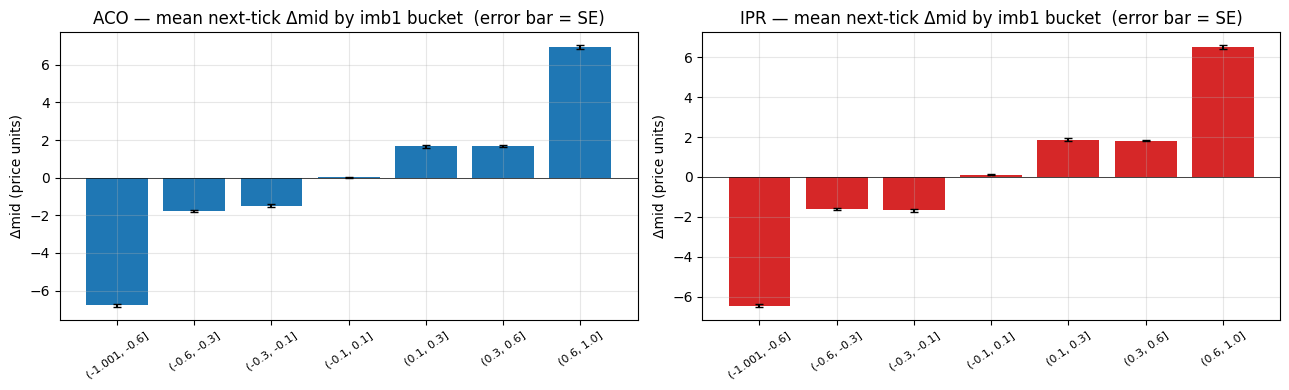

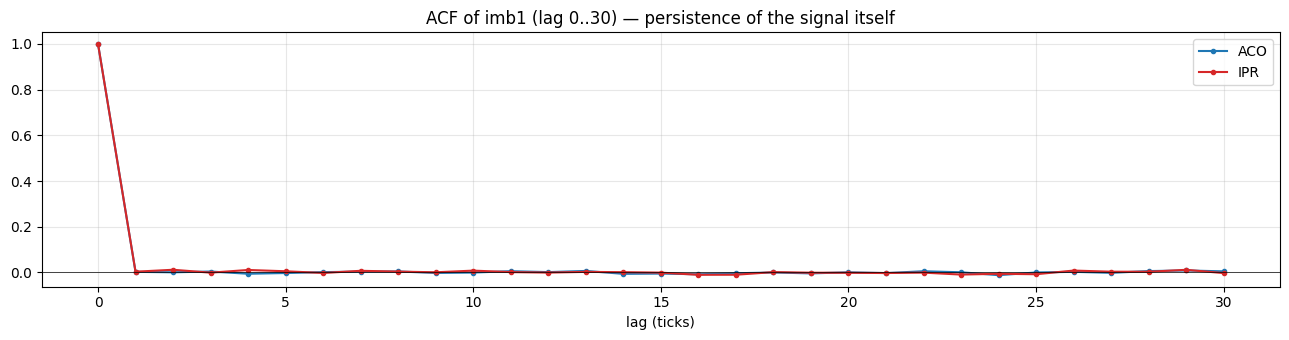

In [19]:
sig = prices.copy().sort_values(["product", "t"])
# drop stale / empty book rows whose mid is 0 or missing — these inject
# spurious ±10_000 jumps that swamp the real short-horizon signal.
sig = sig[(sig["mid_price"] > 0) & sig["mid_price"].notna()].reset_index(drop=True)
bv1 = sig["bid_volume_1"].fillna(0); av1 = sig["ask_volume_1"].fillna(0)
sig["imb1"] = ((bv1 - av1) / (bv1 + av1).replace(0, np.nan))
sig["ret_next"] = sig.groupby("product")["mid_price"].shift(-1) - sig["mid_price"]

BUCKETS = [-1.0, -0.6, -0.3, -0.1, 0.1, 0.3, 0.6, 1.0]
sig["imb_bucket"] = pd.cut(sig["imb1"], BUCKETS, include_lowest=True)

# 1) histograms
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, prod in zip(axes, PRODUCTS):
    x = sig[sig["product"] == prod]["imb1"].dropna()
    ax.hist(x, bins=60, color=COLORS[SHORT[prod]], alpha=0.85)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{SHORT[prod]} — imb1 distribution  (mean={x.mean():+.3f}, |x|>0.3 in {(x.abs()>0.3).mean()*100:.1f}% of ticks)")
    ax.set_xlabel("imb1")
plt.tight_layout(); plt.show()

# 2) bucketed next-tick return
print("mean next-tick Δmid per imb1 bucket (price units):")
print(sig.groupby(["product", "imb_bucket"], observed=True)["ret_next"].agg(["mean", "std", "count"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, prod in zip(axes, PRODUCTS):
    sub = sig[sig["product"] == prod]
    means = sub.groupby("imb_bucket", observed=True)["ret_next"].mean()
    stds = sub.groupby("imb_bucket", observed=True)["ret_next"].std()
    ns = sub.groupby("imb_bucket", observed=True)["ret_next"].count()
    ax.bar(range(len(means)), means.values, yerr=(stds / np.sqrt(ns)).values,
           color=COLORS[SHORT[prod]], capsize=3)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([str(b) for b in means.index], rotation=35, fontsize=8)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{SHORT[prod]} — mean next-tick Δmid by imb1 bucket  (error bar = SE)")
    ax.set_ylabel("Δmid (price units)")
plt.tight_layout(); plt.show()

# 3) ACF of imb1 itself
LAGS = 30
fig, ax = plt.subplots(figsize=(13, 3.5))
for prod in PRODUCTS:
    x = sig[sig["product"] == prod]["imb1"].fillna(0).values
    if len(x) > LAGS + 10:
        a = acf(x, LAGS)
        ax.plot(range(LAGS + 1), a, "o-", color=COLORS[SHORT[prod]], label=SHORT[prod], ms=3)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"ACF of imb1 (lag 0..{LAGS}) — persistence of the signal itself")
ax.set_xlabel("lag (ticks)")
ax.legend()
plt.tight_layout(); plt.show()

## 13. Do deeper book levels (L2, L3) add signal?

If the answer is "no" (or only marginal), we can safely keep our model in terms of top-of-book only. We build level-aggregated imbalances

`imb_k = (Σ_{i≤k} bid_vol_i − Σ_{i≤k} ask_vol_i) / (Σ_{i≤k} bid_vol_i + Σ_{i≤k} ask_vol_i)`

and regress the next-tick Δmid on all three at once, per product.

_Compares imbalance computed from L1, L1+L2, and L1+L2+L3 by regressing next-tick Δmid on each. The incremental R² tells you whether deeper book levels actually add forecasting power over top-of-book alone — usually they barely do._



=== ACO ===  (n = 29,950)
  corr(imb1, ret_next)   = +0.645
  corr(imb2, ret_next)   = +0.460
  corr(imb3, ret_next)   = +0.406
  OLS  y = +5.86·imb1 +2.52·imb2 -1.31·imb3 +0.01
       R² (all 3 + intercept) = 0.427
       R² using imb1..1          = 0.416
       R² using imb1..2          = 0.426
       R² using imb1..3          = 0.427

=== IPR ===  (n = 29,945)
  corr(imb1, ret_next)   = +0.646
  corr(imb2, ret_next)   = +0.415
  corr(imb3, ret_next)   = +0.376
  OLS  y = +5.49·imb1 +6.77·imb2 -6.20·imb3 +0.11
       R² (all 3 + intercept) = 0.437
       R² using imb1..1          = 0.417
       R² using imb1..2          = 0.420
       R² using imb1..3          = 0.437


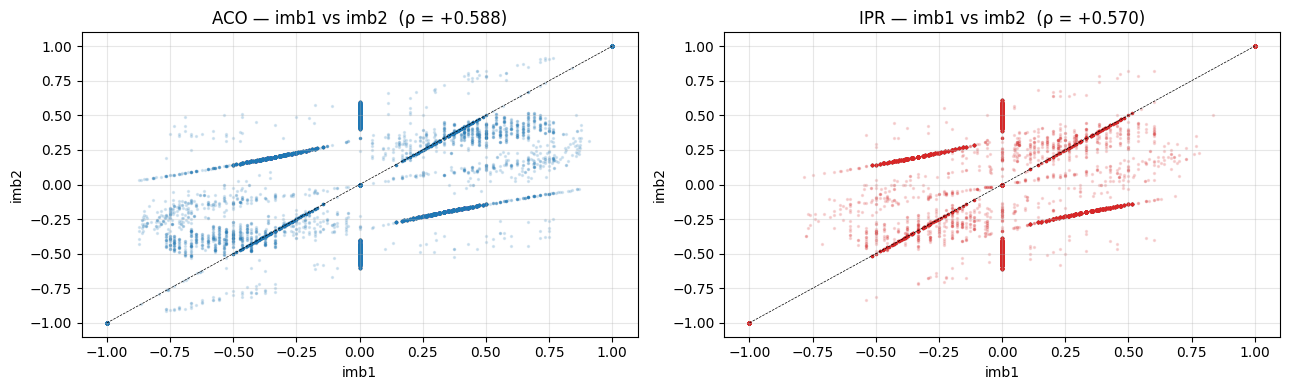

In [20]:
def agg_imb(df, kmax):
    bv = sum(df[f"bid_volume_{k}"].fillna(0) for k in range(1, kmax + 1))
    av = sum(df[f"ask_volume_{k}"].fillna(0) for k in range(1, kmax + 1))
    return (bv - av) / (bv + av).replace(0, np.nan)

deep = prices.copy().sort_values(["product", "t"])
deep = deep[(deep["mid_price"] > 0) & deep["mid_price"].notna()].reset_index(drop=True)
deep["imb1"] = agg_imb(deep, 1)
deep["imb2"] = agg_imb(deep, 2)
deep["imb3"] = agg_imb(deep, 3)
deep["ret_next"] = deep.groupby("product")["mid_price"].shift(-1) - deep["mid_price"]

for prod in PRODUCTS:
    sub = deep[deep["product"] == prod].dropna(subset=["imb1", "imb2", "imb3", "ret_next"])
    print(f"\n=== {SHORT[prod]} ===  (n = {len(sub):,})")
    for k in (1, 2, 3):
        r = sub[f"imb{k}"].corr(sub["ret_next"])
        print(f"  corr(imb{k}, ret_next)   = {r:+.3f}")

    X = sub[["imb1", "imb2", "imb3"]].values
    y = sub["ret_next"].values
    Xa = np.c_[X, np.ones(len(X))]
    beta, *_ = np.linalg.lstsq(Xa, y, rcond=None)
    y_hat = Xa @ beta
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    print(f"  OLS  y = {beta[0]:+.2f}·imb1 {beta[1]:+.2f}·imb2 {beta[2]:+.2f}·imb3 {beta[3]:+.2f}")
    print(f"       R² (all 3 + intercept) = {r2:.3f}")

    # Incremental R² per level
    for kmax in (1, 2, 3):
        Xk = sub[[f"imb{i}" for i in range(1, kmax + 1)]].values
        Xka = np.c_[Xk, np.ones(len(Xk))]
        bk, *_ = np.linalg.lstsq(Xka, y, rcond=None)
        yhk = Xka @ bk
        r2k = 1.0 - float(np.sum((y - yhk) ** 2)) / ss_tot
        print(f"       R² using imb1..{kmax}          = {r2k:.3f}")

# Scatter of imb1 vs imb2 to see if they are essentially the same thing
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, prod in zip(axes, PRODUCTS):
    sub = deep[deep["product"] == prod].dropna(subset=["imb1", "imb2"])
    ax.scatter(sub["imb1"], sub["imb2"], s=2, alpha=0.15, color=COLORS[SHORT[prod]])
    ax.plot([-1, 1], [-1, 1], color="k", lw=0.5, ls="--")
    ax.set_xlabel("imb1"); ax.set_ylabel("imb2")
    ax.set_title(f"{SHORT[prod]} — imb1 vs imb2  (ρ = {sub['imb1'].corr(sub['imb2']):+.3f})")
plt.tight_layout(); plt.show()

## 14. Trade aggressor flow

A trade that prints **above** the prevailing mid is a **buy-aggressor** (someone crossed the spread to buy); **below** the mid is a **sell-aggressor**. Cumulative signed volume tells us whether flow is systematically one-sided on a given product, which is exactly the asymmetric flow our MM needs to know about when setting a quote skew.

_Trade aggressor classification: trades above mid = buyer crossed, trades below = seller crossed. Cumulative signed volume drifts with one-sided flow. Sustained drift = order-flow asymmetry you should skew quotes against._


trade aggressor summary:
                      n_trades  buy_agg_frac  sell_agg_frac  mid_trade_frac  \
symbol                                                                        
ASH_COATED_OSMIUM         1265         0.496          0.475           0.028   
INTARIAN_PEPPER_ROOT      1011         0.466          0.494           0.041   

                      net_signed_qty  gross_qty  
symbol                                           
ASH_COATED_OSMIUM                134       6593  
INTARIAN_PEPPER_ROOT            -124       5230  


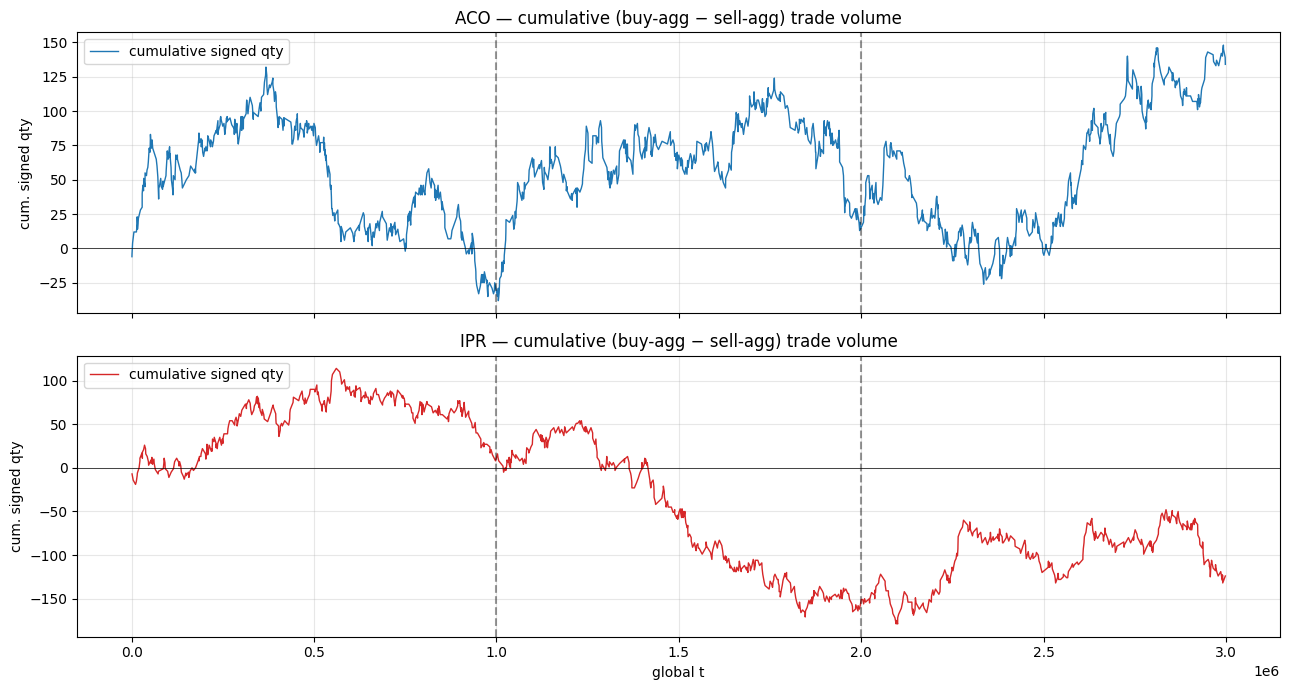

In [21]:
trade_parts = []
for prod in PRODUCTS:
    mid_prod = (
        prices[prices["product"] == prod][["t", "mid_price"]]
        .dropna()
        .sort_values("t")
    )
    tr = trades[trades["symbol"] == prod][["t", "price", "quantity"]].sort_values("t")
    merged = pd.merge_asof(tr, mid_prod, on="t", direction="backward")
    merged["symbol"] = prod
    trade_parts.append(merged)
flow = pd.concat(trade_parts, ignore_index=True)

flow["sign"] = np.where(flow["price"] > flow["mid_price"], 1,
                 np.where(flow["price"] < flow["mid_price"], -1, 0))
flow["signed_qty"] = flow["sign"] * flow["quantity"]

summary = flow.groupby("symbol").agg(
    n_trades=("quantity", "count"),
    buy_agg_frac=("sign", lambda s: (s == 1).mean()),
    sell_agg_frac=("sign", lambda s: (s == -1).mean()),
    mid_trade_frac=("sign", lambda s: (s == 0).mean()),
    net_signed_qty=("signed_qty", "sum"),
    gross_qty=("quantity", "sum"),
)
print("trade aggressor summary:")
print(summary.round(3))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, prod in zip(axes, PRODUCTS):
    sub = flow[flow["symbol"] == prod].sort_values("t")
    ax.plot(sub["t"], sub["signed_qty"].cumsum(), color=COLORS[SHORT[prod]], lw=1.0,
            label="cumulative signed qty")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{SHORT[prod]} — cumulative (buy-agg − sell-agg) trade volume")
    ax.set_ylabel("cum. signed qty")
    ax.legend(loc="upper left")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[-1].set_xlabel("global t")
plt.tight_layout(); plt.show()

## 15. Spread-conditioned return statistics

Splits ticks by the current bid-ask spread and reports mean & std of the next-tick Δmid. Two uses:

- **MM sanity check** — on wide-spread ticks the theoretical passive edge is larger, but adverse selection is also typically bigger. Comparing mean vs std tells us if the edge actually shows up.
- **Take threshold tuning** — if we know |Δmid| conditioned on spread is only, say, ~1 tick even when the spread is 8, taking through the spread is rarely profitable.

_Mean & std of next-tick Δmid bucketed by current spread, plus the joint spread × imb1 table at the end. Wide-spread ticks have larger theoretical passive edge AND larger adverse-selection cost — comparing mean to std tells you if the edge actually materialises before being eaten._


spread-conditioned next-tick Δmid:
                                    count   mean    std
product              spread_bucket                     
ASH_COATED_OSMIUM    [4, 6)           154  5.149  2.560
                     [6, 8)           492 -1.208  5.519
                     [8, 12)         1399  0.014  4.452
                     [12, 20)       24927 -0.004  2.766
                     [20, 40)         671  0.202  2.745
INTARIAN_PEPPER_ROOT [2, 4)           655  1.437  5.023
                     [4, 6)           187 -1.941  5.283
                     [6, 8)           123 -1.252  5.342
                     [8, 12)         3405  0.070  2.137
                     [12, 20)       23162  0.116  2.372
                     [20, 40)         155  0.203  2.322


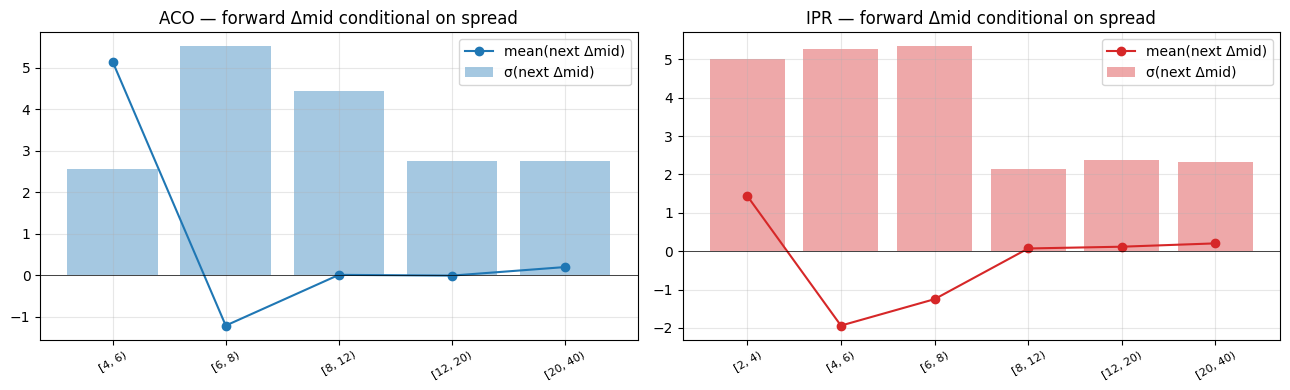


mean next-tick Δmid  —  rows: spread bucket, cols: imb1 bucket:
imb_bucket                           neg  flat   pos
product              spread_bucket                  
ASH_COATED_OSMIUM    [4, 6)          NaN  5.57  4.62
                     [6, 8)        -4.66 -1.22  5.23
                     [8, 12)       -3.31   NaN  3.54
                     [12, 20)      -1.48  0.02  1.30
                     [20, 40)        NaN  0.20   NaN
INTARIAN_PEPPER_ROOT [2, 4)        -4.23  1.54  4.88
                     [4, 6)        -4.71 -4.94  6.42
                     [6, 8)        -5.91  1.95  5.82
                     [8, 12)       -2.47  0.07  2.36
                     [12, 20)      -1.33  0.12  1.53
                     [20, 40)        NaN  0.20   NaN


In [22]:
sc = prices.copy().sort_values(["product", "t"])
sc = sc[(sc["mid_price"] > 0) & sc["mid_price"].notna()].reset_index(drop=True)
sc["spread"] = sc["ask_price_1"] - sc["bid_price_1"]
sc["ret_next"] = sc.groupby("product")["mid_price"].shift(-1) - sc["mid_price"]

EDGES = [0, 2, 4, 6, 8, 12, 20, 40, 200]
sc["spread_bucket"] = pd.cut(sc["spread"], EDGES, right=False)

tbl = (sc.dropna(subset=["ret_next", "spread"])
         .groupby(["product", "spread_bucket"], observed=True)["ret_next"]
         .agg(["count", "mean", "std"])
         .round(3))
print("spread-conditioned next-tick Δmid:")
print(tbl)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, prod in zip(axes, PRODUCTS):
    t = tbl.loc[prod]
    xs = np.arange(len(t))
    ax.bar(xs, t["std"].values, color=COLORS[SHORT[prod]], alpha=0.4,
           label="σ(next Δmid)")
    ax.plot(xs, t["mean"].values, color=COLORS[SHORT[prod]], marker="o",
            label="mean(next Δmid)")
    ax.set_xticks(xs)
    ax.set_xticklabels([str(b) for b in t.index], rotation=30, fontsize=8)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{SHORT[prod]} — forward Δmid conditional on spread")
    ax.legend()
plt.tight_layout(); plt.show()

# Spread-vs-imbalance joint: does imb1 matter more when the book is wide?
sc["imb1"] = ((sc["bid_volume_1"].fillna(0) - sc["ask_volume_1"].fillna(0))
              / (sc["bid_volume_1"].fillna(0) + sc["ask_volume_1"].fillna(0)).replace(0, np.nan))
sc["imb_bucket"] = pd.cut(sc["imb1"], [-1, -0.3, 0.3, 1], labels=["neg", "flat", "pos"])
joint = (sc.dropna(subset=["ret_next", "imb_bucket", "spread_bucket"])
           .groupby(["product", "spread_bucket", "imb_bucket"], observed=True)["ret_next"]
           .mean()
           .unstack("imb_bucket")
           .round(2))
print("\nmean next-tick Δmid  —  rows: spread bucket, cols: imb1 bucket:")
print(joint)